# Solubility prediction from molecular descriptors

1. Dataset: supplied Delaney/ESOL solubility.csv (1,128 compounds). 
2. Target: measured log solubility in mols per litre (logS).
3. Question: How accurately can a random forest predict logS from the six supplied numeric structure descriptors?

Run all cells with solubility.csv beside this notebook. Required packages: pandas, numpy, matplotlib, seaborn, scikit-learn. No RDKit is required.

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

## 1. Load and Explore the Dataset

We first load the dataset and examine its first five rows to understand
the columns and the information recorded for each compound.

In [87]:
df = pd.read_csv("solubility.csv")
df.head(10)

,Compound ID,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,2,84.143,0,1,0,0.00,-1.33,c1ccsc1
5,benzothiazole,2,135.191,0,2,0,12.89,-1.50,c2ccc1scnc1c2
6,"2,2,4,6,6'-PCB",1,326.437,0,2,1,0.00,-7.32,Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl
7,Estradiol,1,272.388,2,4,0,40.46,-5.03,CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O
8,Dieldrin,1,380.913,0,5,0,12.53,-6.29,ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl
9,Rotenone,1,394.423,0,5,3,63.22,-4.42,COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C


In [88]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1128, 9)


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Compound ID                                1128 non-null   str    
 1   Minimum Degree                             1128 non-null   int64  
 2   Molecular Weight                           1128 non-null   float64
 3   Number of H-Bond Donors                    1128 non-null   int64  
 4   Number of Rings                            1128 non-null   int64  
 5   Number of Rotatable Bonds                  1128 non-null   int64  
 6   Polar Surface Area                         1128 non-null   float64
 7   measured log solubility in mols per litre  1128 non-null   float64
 8   smiles                                     1128 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 79.4 KB


In [90]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Minimum Degree,1128.0,1.059,0.239,0.000,1.000,1.000,1.000,2.000
Molecular Weight,1128.0,203.937,102.738,16.043,121.183,182.179,270.372,780.949
Number of H-Bond Donors,1128.0,0.701,1.090,0.000,0.000,0.000,1.000,11.000
Number of Rings,1128.0,1.391,1.318,0.000,0.000,1.000,2.000,8.000
Number of Rotatable Bonds,1128.0,2.177,2.641,0.000,0.000,1.000,3.000,23.000
Polar Surface Area,1128.0,34.873,35.384,0.000,0.000,26.300,55.440,268.680
measured log solubility in mols per litre,1128.0,-3.050,2.096,-11.600,-4.318,-2.860,-1.600,1.580


### Initial Findings

The dataset contains 1,128 compounds and 9 columns.

It includes compound names, SMILES strings, six numeric molecular
descriptors, and the measured log solubility target.

The target ranges from -11.60 to 1.58, showing that the dataset contains
compounds with a wide range of solubility values.

SMILES represents molecular structure as text. In this project, we use
the supplied numeric descriptors rather than processing SMILES directly.

## 2. Check Data Quality

Before modelling, we check for missing values and duplicate records.
We also check for repeated SMILES strings, which could indicate repeated
chemical structures.

In [91]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
Compound ID                                  0
Minimum Degree                               0
Molecular Weight                             0
Number of H-Bond Donors                      0
Number of Rings                              0
Number of Rotatable Bonds                    0
Polar Surface Area                           0
measured log solubility in mols per litre    0
smiles                                       0
dtype: int64

Duplicate rows: 0


In [92]:
df.duplicated(subset="smiles").sum()

np.int64(0)

### Data Quality Findings

There are no missing values, duplicate rows, or repeated SMILES strings.

Therefore, no missing-value imputation or duplicate removal is needed.
We retain all 1,128 records.

## 3. Exploratory Data Analysis

We examine the distribution of measured solubility and the correlations
between numeric variables.

These plots help us understand the data before training the models.
Correlations describe associations and do not establish causation.

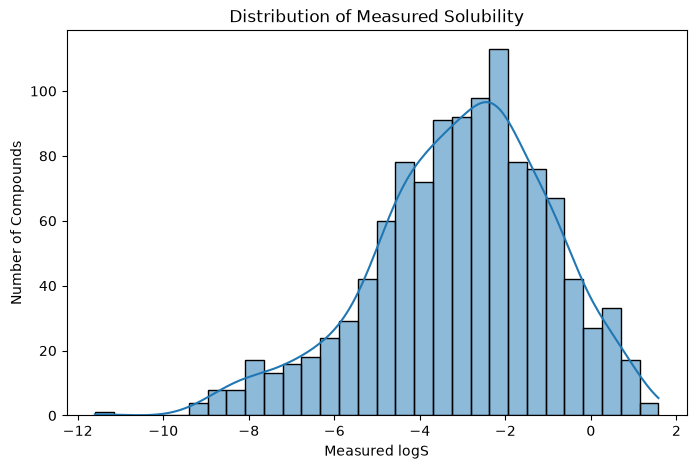

In [93]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["measured log solubility in mols per litre"],
    bins=30,
    kde=True
)

plt.title("Distribution of Measured Solubility")
plt.xlabel("Measured logS")
plt.ylabel("Number of Compounds")
plt.show()

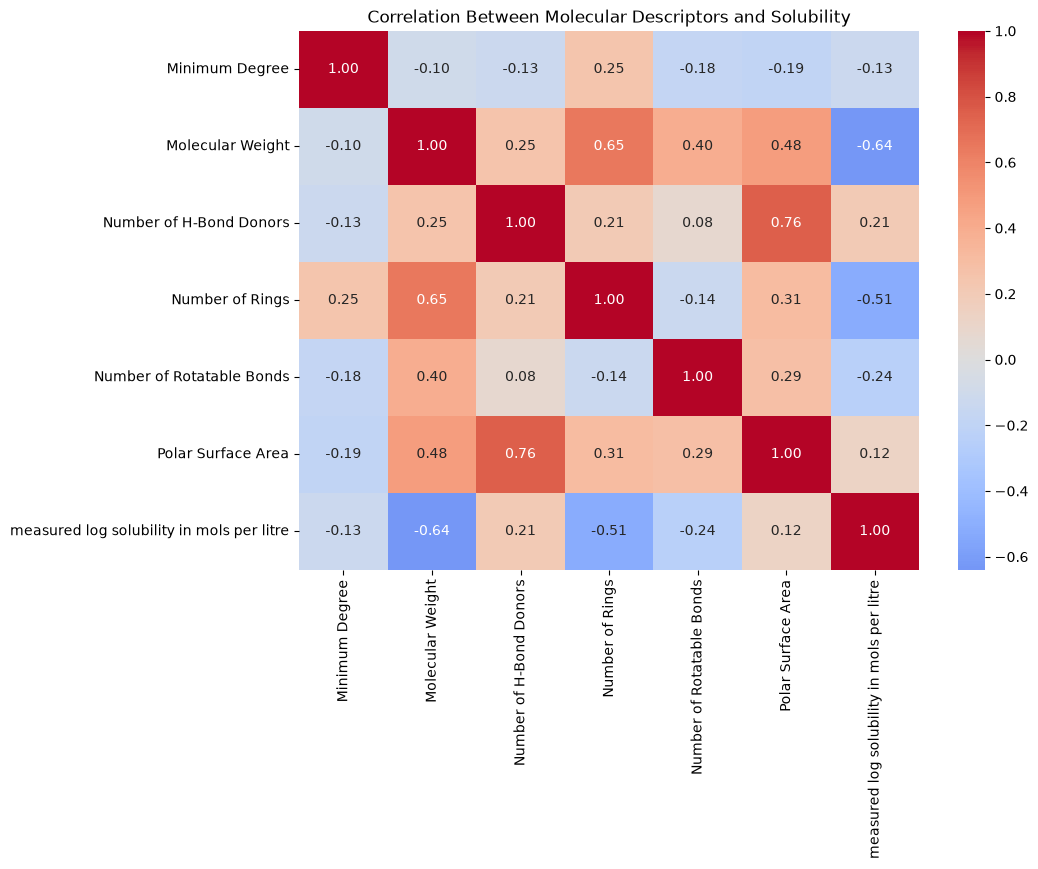

In [94]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Molecular Descriptors and Solubility")
plt.show()

### EDA Findings

The mean measured logS is approximately -3.05, and the median is -2.86.
Most recorded values are negative.

The heatmap shows how the descriptors are linearly associated with one
another and with solubility. Correlated predictors may contain overlapping
information.

These correlations alone do not identify the best model: molecular
properties may also have nonlinear relationships and interactions.

## 4. Prepare the Data for Modelling

We separate the molecular descriptors from the target variable.

Compound ID is excluded because it identifies the compound. SMILES is
excluded because these models require numeric inputs and we have not
converted the strings into additional chemical features.

We use 80% of the data for training and 20% for testing. A fixed random
state makes the split reproducible.

Feature scaling is not required for Random Forest. We also use the
original descriptor values for this ordinary Linear Regression model.

In [95]:
X = df.drop(columns=[
    "Compound ID",
    "smiles",
    "measured log solubility in mols per litre"
])

y = df["measured log solubility in mols per litre"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((902, 6), (226, 6))

## 5. Model Selection and Training

### Linear Regression

Linear Regression provides a simple baseline. It models logS as a linear
combination of the molecular descriptors.

### Random Forest Regression

Random Forest combines predictions from multiple decision trees. It can
capture nonlinear relationships and interactions between descriptors.

We use 500 trees and a fixed random state. The test set is not used to
tune either model.

In [97]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)

In [98]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

## 6. Model Evaluation

We evaluate both models using:

- **MSE:** mean squared prediction error. Lower is better.
- **RMSE:** prediction error expressed in logS units. Lower is better.
- **R²:** performance relative to predicting the mean of the evaluated
  data. Higher is better.

We also compare training and test R² to identify a generalization gap.
R² is not the percentage of compounds predicted correctly.

In [99]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Train R²": [
        r2_score(y_train, lr_train_pred),
        r2_score(y_train, rf_train_pred)
    ],
    "Test MSE": [
        mean_squared_error(y_test, lr_test_pred),
        mean_squared_error(y_test, rf_test_pred)
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_test_pred)),
        np.sqrt(mean_squared_error(y_test, rf_test_pred))
    ],
    "Test R²": [
        r2_score(y_test, lr_test_pred),
        r2_score(y_test, rf_test_pred)
    ]
})

results.round(3)

,Model,Train R²,Test MSE,Test RMSE,Test R²
0,Linear Regression,0.681,1.437,1.199,0.696
1,Random Forest,0.974,0.814,0.902,0.828


### Evaluation Findings

Linear Regression achieved a test MSE of 1.437, RMSE of 1.199, and R² of
0.696.

Random Forest achieved a test MSE of 0.815, RMSE of 0.903, and R² of 0.827.
It performed better on all three test metrics.

The Random Forest explains approximately 82.7% of the variation in
held-out logS for this split. However, its training R² of 0.974 is higher
than its test R² of 0.827, suggesting some overfitting.

Linear Regression has a training R² of 0.681 and test R² of 0.696.
A slightly higher test score can occur because the two sets contain
different samples.

## 7. Visualize Predictions

We compare predicted and measured solubility for both models.

Points close to the dashed diagonal represent more accurate predictions.
Points farther from the line represent larger prediction errors.

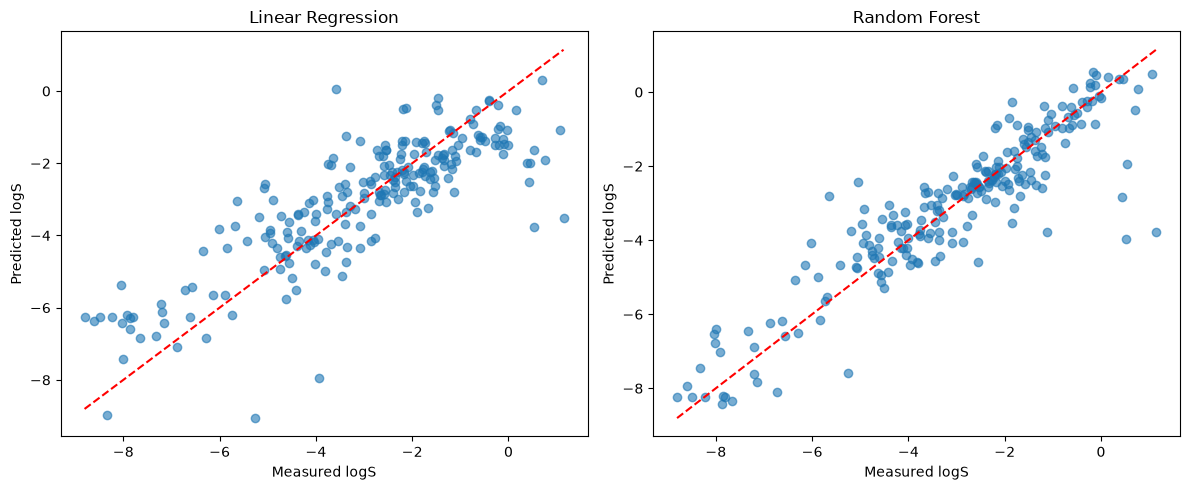

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, lr_test_pred, alpha=0.6)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")

axes[1].scatter(y_test, rf_test_pred, alpha=0.6)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Measured logS")
axes[1].set_ylabel("Predicted logS")

plt.tight_layout()
plt.show()

## 8. Examine Random Forest Residuals

A residual is the measured value minus the predicted value.

We plot residuals against predictions to check for patterns and large
errors. A positive residual means the model underestimated logS; a
negative residual means it overestimated logS.

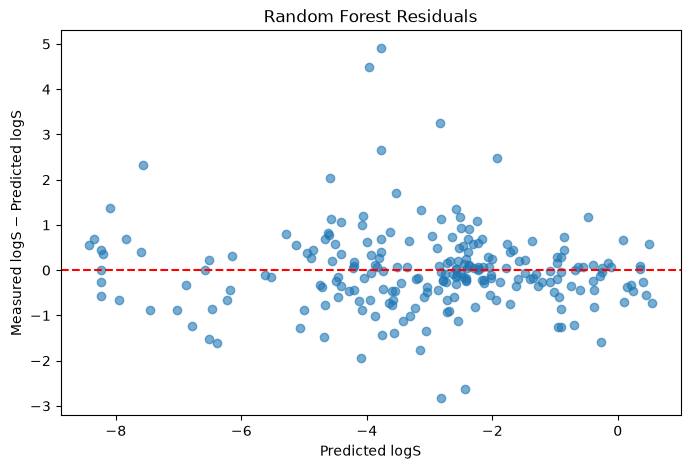

In [101]:
residuals = y_test - rf_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_test_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.title("Random Forest Residuals")
plt.xlabel("Predicted logS")
plt.ylabel("Measured logS − Predicted logS")
plt.show()

## 9. Feature Importance

We examine the Random Forest's feature importance to identify which
descriptors contribute most to its tree splits.

These scores describe model reliance. They do not establish causal
chemical effects or indicate whether a feature increases or decreases
solubility.

In [102]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.round(3)

Molecular Weight             0.583
Polar Surface Area           0.249
Number of Rings              0.067
Number of Rotatable Bonds    0.059
Number of H-Bond Donors      0.039
Minimum Degree               0.004
dtype: float64

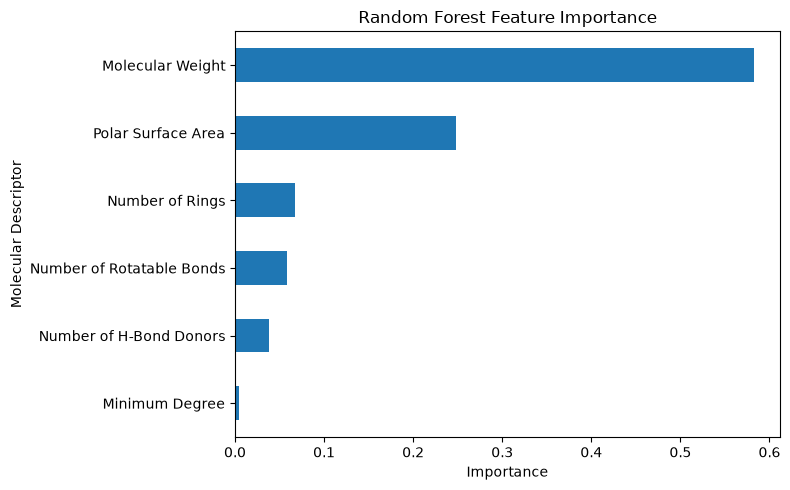

In [103]:
importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Molecular Descriptor")
plt.tight_layout()
plt.show()

### Feature Importance Findings

Molecular Weight has the highest importance at approximately 0.583,
followed by Polar Surface Area at 0.248.

Together, these two descriptors account for approximately 83.1% of the
forest's impurity-based feature importance. The model relies heavily on
them when making predictions.

Ring count, rotatable bonds, hydrogen-bond donors, and minimum degree
have lower importance in this fitted model.

A low score does not prove that a property is chemically unimportant.
Correlated descriptors can share information, and impurity-based
importance can favour features with more possible split values.

## 10. Discussion

### How well does the model predict solubility?

Random Forest performed better than Linear Regression on the test set.
Its test R² of 0.827 shows that it captures much of the variation in logS
for these held-out compounds.

However, its RMSE of 0.903 logS remains substantial for individual
predictions. The difference between training and test performance also
suggests some overfitting. The model is useful for this predictive
exercise, but these results do not demonstrate reliable performance
across all chemical structures.

### Which chemical features significantly influence predictions?

Molecular Weight and Polar Surface Area have the highest importance in
the Random Forest.

These findings suggest that molecular size and polarity provide useful
predictive information within the supplied descriptor set. However,
feature importance does not establish statistical significance,
causation, or the direction of an effect.

### Challenges and Limitations

- Only six numeric descriptors are available to the models.
- SMILES strings are not converted into molecular fingerprints.
- One random split may place chemically similar compounds in both sets.
- The Random Forest shows a training/test performance gap.
- Experimental conditions and other chemical properties are not included.
- Feature importance can be affected by correlated predictors.

### Potential Improvements

- Use cross-validation on the training data to assess model stability.
- Tune Random Forest complexity using training folds.
- Add descriptors such as lipophilicity or molecular fingerprints.
- Use scaffold-based splitting to test unfamiliar chemical families.
- Examine large residuals to identify compounds the model struggles with.

## Conclusion

Random Forest was the better-performing model in this comparison,
achieving a test R² of 0.827 and RMSE of 0.903 logS.

Molecular Weight and Polar Surface Area were its most influential
predictors. Further validation and richer molecular features would be
needed to assess generalization beyond this dataset.

## Reference

Delaney, J. S. (2004). ESOL: Estimating Aqueous Solubility Directly from
Molecular Structure. Journal of Chemical Information and Computer
Sciences, 44(3), 1000–1005.